# Notebook 4 — Age-specific impact functions for heat mortality

This notebook builds **age-differentiated heat–mortality impact functions (IFs)** and links them to the daily T2M hazard and exposures produced in previous notebooks. The IFs express **excess heat deaths relative to a comfortable reference temperature (20 °C)** and are implemented in CLIMADA for pixel-wise risk calculations.

---

## 1. Inputs and setup

- Load **city** configuration, paths, and common objects from previous notebooks:
  - Daily **T2M hazard** on the UrbClim grid (`hazard_T2M_daily_rome.h5`), one event per day for 2030, 2040, 2050.
  - **Exposures** with age groups `<15`, `15–64`, `65+`, population counts, and vulnerability (`exposure_with_vulnerability_rome*.h5`).
- Repair and reattach **daily dates and frequencies** in the hazard:
  - `H.date` set from `hazard_T2M_daily_events_rome.csv`.
  - `H.frequency = 1 / (365 or 366)` so that frequencies **sum to 1 per year**.
- Compute a **city-mean daily T2M series** as a diagnostic (mean over all valid grid cells per day).

---

## 2. Constructing age-specific heat–mortality curves

- Define a **shared temperature grid**:
  - `T_grid = 0–40 °C` (step 0.5 °C), with **reference temperature** `T_ref = 20 °C`, where excess risk is around 0.
- For each age group, fit a **convex power-law tail above 20 °C**:
  - where delta D(T) is **change in deaths per 100,000 people per day**.
  - Choose approximate **anchor points** inspired by an EU-style temperature–mortality figure:
    - 65+ (“elderly”): e.g. ~0.3 per 100k at 24 °C, ~12 per 100k at 35 °C.
    - 15–64 (“adults”): ~0.1 per 100k at 28 °C, ~0.4 per 100k at 35 °C.
    - <15 (“young”): ~0.02 per 100k at 28 °C, ~0.05 per 100k at 35 °C.
  - Solve for \(\beta\) and \(p\) so the curve passes through the chosen points; curves are **monotone and convex** on the hot side.
- Convert **Δ deaths per 100k per day** to **per-person daily death probability** (mdd) for CLIMADA:
  - Interpretation:  
    d extra deaths per 100,000 people per day” ⇒ per-person probability  
  - Clip mdd values to \([0, 1]\); below 20 °C, mdd = 0 (heat-only excess).
- Result: three **age-specific response curves** mdd(T) that say:  
  *if a day has mean T2M = T, then in age group A there is an extra mdd(T) probability of dying due to heat, relative to a 20 °C day.*

---

## 3. City-level diagnostic: manual annual heat deaths

- Using **scenario [choice]** exposures for 2030, 2040, 2050:
  - Build a table of **age-group populations by year** on the T2M grid.
- For each day and age group:
  - Take the **city-mean daily temperature**.
  - Look up **Δ deaths per 100k** from the fitted curve.
  - Multiply by the **age-specific population / 100,000** to get **daily excess deaths**.
- Aggregate over days to get **annual heat-attributable deaths by age**:
  - Also compute **per-100k rates** for each age group.
- This “manual” calculation serves as a **sanity check** and is intentionally simpler:
  - Uses a single **city-mean T per day** (no spatial variation),
  - Whereas CLIMADA later uses **full gridded T2M**.

---

## 4. Implementing impact functions in CLIMADA

- Build **ImpactFunc** objects for hazard type `"T2M"`:
  - All share the same `intensity = T_grid`.
  - `mdd` is age-specific (`young_mdd`, `adult_mdd`, `elderly_mdd`).
  - `paa` (probability of asset affected) = 1 for all intensities.
  - Assign IDs:
    - `<15` → IF id 1,
    - `15–64` → IF id 2,
    - `65+` → IF id 3.
- Create an **ImpactFuncSet** and run CLIMADA’s `ImpactCalc`:
  - For each age group:
    - Copy exposures, **zero out everyone not in that age group**,
    - Set the correct **impact function ID** in the exposure,
    - Compute **impact per event** (deaths per day),
    - Aggregate by year ⇒ **annual heat deaths by age**.
- Compare CLIMADA results vs. manual city-mean results:
  - Differences arise because CLIMADA uses the **full spatial distribution of T2M** (hotter and cooler pixels), not just the city mean.
  - These CLIMADA-based annual deaths are the numbers used later in the pipeline.

---

## 5. Baseline mortality scaling (Wittgenstein / “baseline deaths”)

- Load **baseline all-cause mortality rates** per 100k by age and year (`baselinedeaths.csv`).
- Build a **baseline mortality table** for `<15`, `15–64`, `65+` in 2030, 2040, 2050.
- Compute **scale factors** relative to a reference year (2030):
  - For each age and year
- Apply these scale factors to heat-attributable deaths:
  - Optionally scale both **manual** and **CLIMADA-based** annual deaths:
    - If all-cause mortality falls in an age group, **heat mortality is assumed to fall proportionally** (and vice versa).
  - Compute **absolute deaths** and **per-100k rates**:
    - With and without baseline scaling, to show how assumptions about future vulnerability change the results.

---

## 6. Outputs for following notebooks

This notebook writes out a series of files for later use:

- **Impact function curves**
  - `if_curves_frozen_rome.json` — age-specific T2M IF curves (intensity and mdd arrays) frozen to disk.

- **Baseline and scaling metadata**
  - `baseline_heat_scaling_rome.csv` — baseline mortality scaling factors by age & year.

- **Annual heat mortality summaries (city-level)**
  - Manual (city-mean T):
    - `annual_heat_deaths_manual_rome.csv` — raw annual heat deaths by age.
    - `annual_heat_deaths_manual_scaled_rome.csv` — after baseline scaling.
  - CLIMADA (full grid):
    - `annual_heat_deaths_generic_rome.csv` — raw annual heat deaths by age.
    - `annual_heat_deaths_generic_scaled_rome.csv` — after baseline scaling.

Together, these outputs provide **age-specific, CLIMADA-compatible impact functions for heat**, plus consistent annual mortality summaries under different assumptions about future baseline vulnerability.

In [39]:
import os
os.environ["CITY"] = "rome"   # pick the city here

In [40]:
# generic bootstrap 
from pathlib import Path
import os, sys

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand/"cityheat").is_dir() and (cand/"configs").is_dir():
            return cand
    raise RuntimeError("Repo root not found.")
ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
from cityheat.paths import make_P, ensure_out

# choose city here
SLUG = globals().get("SLUG", os.environ.get("CITY", "rome")).lower()

C    = bootstrap(SLUG)      # reads configs/<slug>.yml and syncs that city only if wanted
CFG  = C["CFG"]; CITY = C["CITY"]
BASE = C["BASE"]; OUT = C["OUT"]; INT = C["INT"]

P    = make_P(BASE)         # read-only path helper
OUTP = ensure_out(OUT)      # write-safe path helper
print(f"→ City: {CITY}  |  BASE={BASE}  OUT={OUT}  INT={INT}")

→ City: rome  |  BASE=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome  OUT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome  INT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim


In [41]:
cfg  = C.get("cfg")     # dict loaded from YAML

**from previous notebooks**

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from climada.hazard import Hazard
from climada.entity.exposures import Exposures
from climada.entity.impact_funcs import ImpactFunc, ImpactFuncSet
from climada.engine import ImpactCalc

plt.rcParams.update({"figure.dpi": 130})

# loading hazard and exposure from previous notebooks 
haz_path = INT / f"hazard_T2M_daily_{SLUG}.h5"
H = Hazard.from_hdf5(haz_path)

# exposure loader
def load_any_exposure(SLUG=SLUG):
    """
    For IF calibration we just need some exposure with age_group and value.
    Trying a list of possible files (with/without vulnerability, scenario/year),
    and picking the first that exists.
    """
    candidates = [
        # baseline with vulnerability from NB3
        INT / f"exposure_with_vulnerability_{SLUG}.h5",
        OUT / f"exposure_with_vulnerability_{SLUG}.h5",

        # a common baseline scenario (e.g. SSP2 2030)
        INT / f"exposure_with_vulnerability_{SLUG}_SSP2_2030.h5",
        OUT / f"exposure_with_vulnerability_{SLUG}_SSP2_2030.h5",

        # legacy names kept for backward compatibility
        INT / f"exposure_people_{SLUG}.h5",
        OUT / f"exposure_people_{SLUG}.h5",
    ]

    for p in candidates:
        if p.exists():
            print(f"→ Using exposure for IF diagnostics: {p}")
            return Exposures.from_hdf5(p)

    raise FileNotFoundError(
        "No exposure HDF5 found for IF notebook. "
        "Re-run Notebook 3 so at least one exposure_with_vulnerability_*.h5 exists."
    )

exp = load_any_exposure()

# loading scenario exposures by year for population diagnostics 

SCEN = "SSP2"
YEARS = [2020, 2030, 2040, 2050]

def load_exposure_by_year(scen_code=SCEN, years=YEARS, SLUG=SLUG):
    exps = {}
    for y in years:
        if y == 2020:
            # 2020 has no SSP file: use baseline-with-vulnerability
            p = INT / f"exposure_with_vulnerability_{SLUG}.h5"
            if not p.exists():
                p = OUT / f"exposure_with_vulnerability_{SLUG}.h5"
            if not p.exists():
                raise FileNotFoundError(f"Missing baseline exposure for 2020: {p}")
        else:
            p = OUT / f"exposure_with_vulnerability_{SLUG}_{scen_code}_{y}.h5"
            if not p.exists():
                p = INT / f"exposure_with_vulnerability_{SLUG}_{scen_code}_{y}.h5"
            if not p.exists():
                raise FileNotFoundError(f"Expected exposure file not found: {p}")

        print(f"→ Loaded exposure for {scen_code if y!=2020 else 'BASE'} {y}: {p}")
        exps[y] = Exposures.from_hdf5(p)

    return exps

exposures_by_year = load_exposure_by_year()

# repairing daily metadata 
def _days_in_year(y):
    return 366 if (y % 4 == 0 and (y % 100 != 0 or y % 400 == 0)) else 365

def reattach_daily_dates(INT, SLUG, H):
    csv = INT / f"hazard_T2M_daily_events_{SLUG}.csv"
    df = pd.read_csv(csv).sort_values("row").reset_index(drop=True)

    n = H.intensity.shape[0]
    assert len(df) == n, f"Events CSV rows ({len(df)}) != hazard rows ({n})."

    H.event_id   = df["event_id"].to_numpy(int)
    H.date       = pd.to_datetime(df["date"]).to_numpy("datetime64[ns]")
    H.event_name = np.array([f"T2M_{d.date()}" for d in pd.to_datetime(df["date"])], dtype=object)

    yrs = pd.to_datetime(df["date"]).dt.year.to_numpy(int)
    H.frequency      = np.array([1.0/_days_in_year(y) for y in yrs], dtype=float)
    H.frequency_unit = "1/year"
    return H

H = reattach_daily_dates(INT, SLUG, H)
H.haz_type = "T2M"
H.units    = "degC (daily mean)"

yrs = pd.to_datetime(H.date).year.to_numpy(int)
print(pd.Series(yrs).value_counts().sort_index())
print(pd.DataFrame({"y": yrs, "f": H.frequency}).groupby("y")["f"].sum())

assert np.allclose(pd.DataFrame({"y": yrs, "f": H.frequency}).groupby("y")["f"].sum().values, 1.0)

if not hasattr(H, "date") or len(getattr(H, "date", [])) != H.intensity.shape[0]:
    raise RuntimeError("Daily dates not present in hazard. Re-run NB3 saving steps.")

# Event-year index from daily dates
dates = pd.to_datetime(pd.Series(H.date.astype("datetime64[ns]")))
year_idx = dates.dt.year.to_numpy(int)  # length = n_days

→ Using exposure for IF diagnostics: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/exposure_with_vulnerability_rome.h5
→ Loaded exposure for BASE 2020: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/exposure_with_vulnerability_rome.h5
→ Loaded exposure for SSP2 2030: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/exposure_with_vulnerability_rome_SSP2_2030.h5
→ Loaded exposure for SSP2 2040: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/exposure_with_vulnerability_rome_SSP2_2040.h5
→ Loaded exposure for SSP2 2050: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/exposure_with_vulnerability_rome_SSP2_2050.h5
2020    366
2030    365
2040    366
2050    365
Name: count, dtype: int64
y
2020    1.0
2030    1.0
2040    1.0
2050    1.0
Name: f, dtype: float64


In [43]:
# H.intensity and H.fraction are sparse (events x cells)
num = H.intensity.multiply(H.fraction).sum(axis=1)   # sum of T over valid cells
den = H.fraction.sum(axis=1)                         # number of valid cells
citymean_daily = (num / den).A1                      # 1D array (length = n_days)

pd.DataFrame({"date": dates, "citymean_degC": citymean_daily}).head(10)

,date,citymean_degC
0,2020-01-01,8.114641
1,2020-01-02,8.449653
2,2020-01-03,9.097731
3,2020-01-04,8.510039
4,2020-01-05,8.540201
5,2020-01-06,8.226512
6,2020-01-07,8.523939
7,2020-01-08,9.279934
8,2020-01-09,9.033796
9,2020-01-10,9.277946


sanity plot of the daily city-mean temps

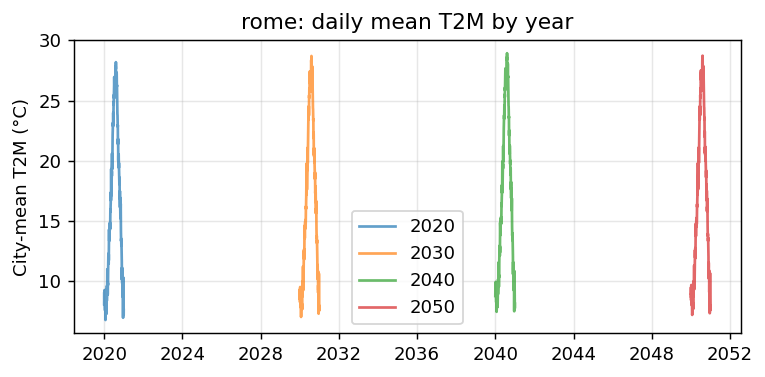

In [44]:
# daily city-mean T2M per year (just for intuition)
daily_df = pd.DataFrame({"date": dates, "citymean_degC": citymean_daily})
daily_df["year"] = daily_df["date"].dt.year

fig, ax = plt.subplots(figsize=(6,3))
for y, sub in daily_df.groupby("year"):
    ax.plot(sub["date"], sub["citymean_degC"], label=y, alpha=0.7)
ax.set_ylabel("City-mean T2M (°C)")
ax.set_title(f"{CITY}: daily mean T2M by year")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

Temperature grid for impact functions

In [45]:
# Intensity axis for all T2M impact functions (0–40 °C)
t_min, t_max, t_step = 0.0, 40.0, 0.5
T_grid = np.arange(t_min, t_max + 1e-6, t_step)  # °C
T_ref  = 20.0  # "comfortable" temperature, where excess risk is around 0

Helper to build a “heat-only” tail: change indeaths per 100k to daily probability

Approximation of each of the curve as a smooth power-law tail above 20 °C that matches a couple of points from the EU figure, then convert “extra deaths per 100,000 people per hot day” into a fraction of people dying that day.

In [46]:
def heat_tail_power(T, T_ref, d1, T1, d2, T2):
    """
    Constructing a convex 'heat-only' curve:
      change deaths per 100k = beta * (T - T_ref)^p  for T > T_ref, else 0
    passing approximately through (T1, d1) and (T2, d2).
    """
    # distance above reference
    h1 = max(T1 - T_ref, 1e-6)
    h2 = max(T2 - T_ref, 1e-6)
    # exponent from the two target points
    p = np.log(d2 / d1) / np.log(h2 / h1)
    beta = d1 / (h1 ** p)
    out = np.zeros_like(T, dtype=float)
    h = np.clip(T - T_ref, 0, None)
    out = beta * np.power(h, p)
    return out, beta, p

- I take the EU figure with change in deaths per 100k ppl per day by age
- I choose anchor points and fir a hot-side curve above 20°
- I convert extra deaths per 100k per day into a per person daily death proba (mdd)
    - Curves say : for each temp T and each age group: at this T, there are this change
      in deaths per 100,000 ppl per day more than at 20°C => d(T)
    - To turn into mdd(T) I interpret the unit: d deaths per 100,000 per day means taking
      100,000 ppl on that day at temperature T, expect d extra deaths.
      Divide by 100,000 to get per person. So d/100,000 : proba one person dies that day.
      Use mdd(T): what CLIMADA expects as mdd onIF : fractionof exposed ppl that die on
      that event/day.
      Feed to CLIMADA as mdd for each age-specifc IF.
      So mdd(T)=change deaths per 100,000 per day at T/100,000
- I plug mdd(T) curves into CLIMADA as age-specific IF
- Then I run CLIMADA with this hazard and those IFs
    - Our hazard (daily mean temperature from UrbClim for 2030, 2040, 2050)
    - One event per day with H.intensity: temp on each grid cell for that day
    - H.fration = pop mask/valid cell mask
    - H.date = actual calendar data
    - H.frequency = 1/365 or 1/366 depending on the year
    - We feed that H and age specific IF mdd(T) into CLIMADA
    - For each day and each grid cell, looks up mdd(T) for that day's temp
    - Multiplies by exposed ppl in that cell/age group
    - sums over cells and days => annual heat-attributable deaths 

We choose rough “anchor points” trying to be as close as possible to the EU panel

- Elderly: about 1 extra death/100k at around 28 °C, around 12 at around 35 °C.

- Adults: about 0.1 at 28 °C, 0.4 at 35 °C.

- Young: tiny effect, say 0.02 at 28 °C, 0.05 at 35 °C.

In [47]:
# Elderly (65+)
elderly_d, elderly_beta, elderly_p = heat_tail_power(
    T_grid, T_ref,
    d1=0.3,  T1=24.0,   # 0.3 per 100k at 24°C
    d2=12.0, T2=35.0    # 12 per 100k at 35°C
)

# Adults (15–64)
adult_d, adult_beta, adult_p = heat_tail_power(
    T_grid, T_ref,
    d1=0.10, T1=28.0,   # 0.1 per 100k at 28°C
    d2=0.40, T2=35.0    # 0.4 per 100k at 35°C
)

# Young (<15)
young_d, young_beta, young_p = heat_tail_power(
    T_grid, T_ref,
    d1=0.02, T1=28.0,   
    d2=0.05, T2=35.0
)

# converting change in deaths per 100k per day to probability per person per day (fraction)
per100k = 100_000.0
elderly_mdd = elderly_d / per100k
adult_mdd   = adult_d   / per100k
young_mdd   = young_d   / per100k

# making sure we never exceed 1 
elderly_mdd = np.clip(elderly_mdd, 0, 1)
adult_mdd   = np.clip(adult_mdd,   0, 1)
young_mdd   = np.clip(young_mdd,   0, 1)

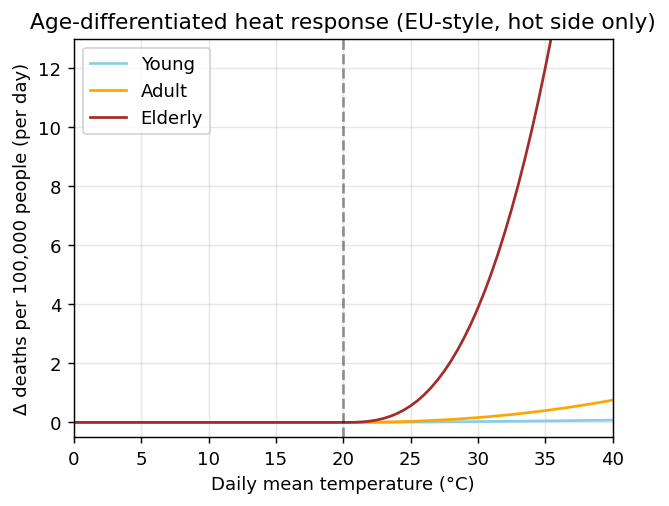

Elderly curve parameters: beta = 0.006264, p = 2.791
Adult   curve parameters: beta = 0.001019, p = 2.205
Young   curve parameters: beta = 0.0009653, p = 1.458


In [48]:
fig, ax = plt.subplots(figsize=(5,4))
ax.plot(T_grid, young_d,   label="Young",  color="skyblue")
ax.plot(T_grid, adult_d,   label="Adult",  color="orange")
ax.plot(T_grid, elderly_d, label="Elderly",color="brown")
ax.axvline(T_ref, color="k", linestyle="--", alpha=0.4)
ax.set_xlim(0, 40)
ax.set_ylim(-0.5, 13)
ax.set_xlabel("Daily mean temperature (°C)")
ax.set_ylabel("Δ deaths per 100,000 people (per day)")
ax.set_title("Age-differentiated heat response (EU-style, hot side only)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print("Elderly curve parameters: beta = %.4g, p = %.3f" % (elderly_beta, elderly_p))
print("Adult   curve parameters: beta = %.4g, p = %.3f" % (adult_beta, adult_p))
print("Young   curve parameters: beta = %.4g, p = %.3f" % (young_beta, young_p))

Age-group populations

In [49]:
# age-group populations using SSP2 projections for each year 

# building a table [year x age_group] with total population from the SSP2 exposures
age_pop_by_year = (
    pd.concat(
        {
            year: exp_y.gdf
                       .groupby("age_group")["value"]
                       .sum()
                       .astype(float)
            for year, exp_y in exposures_by_year.items()
        },
        axis=1,
    )
    .T  # years as rows
    .sort_index()
)

print(f"Population by age group (T2M grid, scenario {SCEN}):")
print(age_pop_by_year)
print("Total population per year:")
print(age_pop_by_year.sum(axis=1))

# for backwards compatibility with the existing code below, keeping a 2020 baseline vector
age_pop = age_pop_by_year.loc[2020].sort_index()
print("\nUsing 2020 age_pop as baseline for some diagnostics;")
print("full time-varying populations are in `age_pop_by_year`.")

Population by age group (T2M grid, scenario SSP2):
age_group         15-64            65+            <15
2020       1.695557e+06  596805.915901  342468.183871
2030       1.580341e+06  690669.415242  277143.778146
2040       1.389094e+06  827504.921228  271843.953003
2050       1.274623e+06  878530.203619  286679.101395
Total population per year:
2020    2.634831e+06
2030    2.548154e+06
2040    2.488442e+06
2050    2.439832e+06
dtype: float64

Using 2020 age_pop as baseline for some diagnostics;
full time-varying populations are in `age_pop_by_year`.


Building interpolation helpers for the curves

In [50]:
import numpy as np
import pandas as pd

# mapping age group to curve in "deaths per 100k per day"
curves_per100k = {
    "<15":   young_d,
    "15-64": adult_d,
    "65+":   elderly_d,
}

def delta_deaths_per100k(T):
    """
    Return a dict {age_group: Δ deaths per 100k per day} 
    for a scalar temperature T (°C).
    """
    out = {}
    for age, curve in curves_per100k.items():
        out[age] = float(np.interp(T, T_grid, curve))
    return out

Turning daily temps into daily excess deaths

In [51]:
# building a DataFrame with one row per day
df = pd.DataFrame({
    "date": dates,
    "temp_degC": citymean_daily,
})
df["year"] = df["date"].dt.year

rows = []
for _, row in df.iterrows():
    T = row["temp_degC"]
    y = row["year"]
    d_per100k = delta_deaths_per100k(T)
    for age in ["<15", "15-64", "65+"]:
        deaths_day = d_per100k[age] * (age_pop_by_year.loc[y, age] / 100_000.0)
        rows.append({
            "date":  row["date"],
            "year":  y,
            "age_group": age,
            "temp_degC": T,
            "delta_deaths": deaths_day,
        })

daily_heat = pd.DataFrame(rows)

In [52]:
daily_heat = pd.DataFrame(rows)

# look at the first few days
print(daily_heat.head())

        date  year age_group  temp_degC  delta_deaths
0 2020-01-01  2020       <15   8.114641           0.0
1 2020-01-01  2020     15-64   8.114641           0.0
2 2020-01-01  2020       65+   8.114641           0.0
3 2020-01-02  2020       <15   8.449653           0.0
4 2020-01-02  2020     15-64   8.449653           0.0


In [53]:
# yearly deaths by age group
yearly = (
    daily_heat
    .groupby(["year", "age_group"])["delta_deaths"]
    .sum()
    .unstack("age_group")          # columns: '<15', '15-64', '65+'
    .fillna(0.0)
)

# renaming columns 
yearly = yearly.rename(
    columns={
        "<15":   "deaths_young",
        "15-64": "deaths_adult",
        "65+":   "deaths_elderly",
    }
)

# adding total across ages
yearly["deaths_total"] = (
    yearly["deaths_young"]
    + yearly["deaths_adult"]
    + yearly["deaths_elderly"]
)

print(yearly)

age_group  deaths_adult  deaths_elderly  deaths_young  deaths_total
year                                                               
2020          78.651078      493.036322      3.993943    575.681343
2030          88.004245      711.273473      3.701815    802.979533
2040          83.279340      933.979591      3.825993   1021.084924
2050          72.349623      925.514794      3.885927   1001.750343


Aggregate to annual totals and rates per 100k

In [54]:
# Annual deaths by age group
annual_by_age = (
    daily_heat
    .groupby(["year", "age_group"])["delta_deaths"]
    .sum()
    .unstack("age_group")
)

print("Annual heat deaths (absolute):")
print(annual_by_age)

# Annual rates per 100k in each age group
annual_rates_per100k = annual_by_age.copy()
for age in ["<15", "15-64", "65+"]:
    # age_pop_by_year[age] is a Series indexed by year, so this aligns correctly
    annual_rates_per100k[age] = (
        annual_by_age[age] / (age_pop_by_year[age] / 100_000.0)
    )

print("\nAnnual heat deaths per 100k, by age group:")
print(annual_rates_per100k)

Annual heat deaths (absolute):
age_group      15-64         65+       <15
year                                      
2020       78.651078  493.036322  3.993943
2030       88.004245  711.273473  3.701815
2040       83.279340  933.979591  3.825993
2050       72.349623  925.514794  3.885927

Annual heat deaths per 100k, by age group:
age_group     15-64         65+       <15
year                                     
2020       4.638657   82.612506  1.166223
2030       5.568688  102.983201  1.335702
2040       5.995229  112.866953  1.407423
2050       5.676158  105.348090  1.355497


**Into CLIMADA: pixel-wise, not city-mean anymore**

In [55]:
from climada.entity.impact_funcs import ImpactFunc, ImpactFuncSet

# making sure T_grid and *_mdd are numpy arrays
T_arr      = np.asarray(T_grid, float)
young_arr  = np.asarray(young_mdd, float)
adult_arr  = np.asarray(adult_mdd, float)
elderly_arr= np.asarray(elderly_mdd, float)

# sanity check (monotone, between 0 and 1)
for lbl, arr in [("<15", young_arr), ("15-64", adult_arr), ("65+", elderly_arr)]:
    assert np.all(arr >= 0) and np.all(arr <= 1), f"{lbl} mdd outside [0,1]"

age_ifs = {
    "<15": ImpactFunc(
        haz_type="T2M",
        id=1,
        intensity=T_arr,
        mdd=young_arr,
        paa=np.ones_like(T_arr),
        name="<15",
    ),
    "15-64": ImpactFunc(
        haz_type="T2M",
        id=2,
        intensity=T_arr,
        mdd=adult_arr,
        paa=np.ones_like(T_arr),
        name="15–64",
    ),
    "65+": ImpactFunc(
        haz_type="T2M",
        id=3,
        intensity=T_arr,
        mdd=elderly_arr,
        paa=np.ones_like(T_arr),
        name="65+",
    ),
}

ifs = ImpactFuncSet(list(age_ifs.values()))
ifs.check()  # will raise if something is inconsistent
print("Built age-specific T2M impact functions:", [f"{k}→{v.id}" for k, v in age_ifs.items()])

Built age-specific T2M impact functions: ['<15→1', '15-64→2', '65+→3']


In [56]:
from climada.engine import ImpactCalc
from climada.entity.exposures import Exposures
import pandas as pd
import numpy as np

# mapping age label -> ImpactFunc id
age_to_if_id = {"<15": 1, "15-64": 2, "65+": 3}

# year index from hazard dates (one per event/day)
year_idx = pd.to_datetime(H.date.astype("datetime64[ns]")).year

climada_annual = {}

for age_lbl in ["<15", "15-64", "65+"]:
    # filter to this age group (so we don't need impf=0 anywhere)
    gdf_age = exp.gdf.loc[exp.gdf["age_group"] == age_lbl].copy()

    # assign correct impact function id to ALL rows
    gdf_age["impf_T2M"] = age_to_if_id[age_lbl]

    # build a fresh Exposures (can't assign exp_age.gdf directly)
    exp_age = Exposures()
    exp_age.set_gdf(gdf_age)
    exp_age.value_unit = getattr(exp, "value_unit", "people")
    exp_age.ref_year   = getattr(exp, "ref_year", None)

    # run CLIMADA
    imp = ImpactCalc(exp_age, ifs, H).impact(save_mat=False)

    # aggregate daily deaths -> annual deaths
    climada_annual[age_lbl] = pd.Series(imp.at_event).groupby(year_idx).sum()

In [57]:
print("Annual heat deaths (absolute):")
print(annual_by_age)

Annual heat deaths (absolute):
age_group      15-64         65+       <15
year                                      
2020       78.651078  493.036322  3.993943
2030       88.004245  711.273473  3.701815
2040       83.279340  933.979591  3.825993
2050       72.349623  925.514794  3.885927


In [58]:
# CLIMADA-based annual heat deaths using generic EU IFs (no explicit AC attenuation)

heat_deaths_generic = pd.DataFrame(climada_annual)[["15-64", "65+", "<15"]]
print(heat_deaths_generic)

print("Generic annual heat deaths from CLIMADA (absolute):")
print(heat_deaths_generic)

           15-64         65+       <15
2020   85.537763  552.656406  4.214292
2030  102.033634  682.573274  4.809350
2040  109.574337  745.259380  5.061408
2050  103.942192  697.625491  4.879260
Generic annual heat deaths from CLIMADA (absolute):
           15-64         65+       <15
2020   85.537763  552.656406  4.214292
2030  102.033634  682.573274  4.809350
2040  109.574337  745.259380  5.061408
2050  103.942192  697.625491  4.879260


In [59]:
compare = []

for age_lbl in ["<15", "15-64", "65+"]:
    s_manual = annual_by_age[age_lbl]
    s_clim   = climada_annual[age_lbl]
    df_cmp = pd.DataFrame({
        "manual": s_manual,
        "climada": s_clim,
        "diff": s_clim - s_manual,
        "rel_diff_%": 100 * (s_clim - s_manual) / s_manual
    })
    print(f"\n=== Age group {age_lbl} ===")
    print(df_cmp)
    compare.append(df_cmp)


=== Age group <15 ===
        manual   climada      diff  rel_diff_%
2020  3.993943  4.214292  0.220349    5.517086
2030  3.701815  4.809350  1.107534   29.918682
2040  3.825993  5.061408  1.235415   32.290033
2050  3.885927  4.879260  0.993334   25.562336

=== Age group 15-64 ===
         manual     climada       diff  rel_diff_%
2020  78.651078   85.537763   6.886685    8.755996
2030  88.004245  102.033634  14.029389   15.941719
2040  83.279340  109.574337  26.294997   31.574454
2050  72.349623  103.942192  31.592569   43.666529

=== Age group 65+ ===
          manual     climada        diff  rel_diff_%
2020  493.036322  552.656406   59.620084   12.092432
2030  711.273473  682.573274  -28.700199   -4.035044
2040  933.979591  745.259380 -188.720212  -20.206032
2050  925.514794  697.625491 -227.889303  -24.622978


<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
why the small differences? citymean_daily: turning each day's T into a change in deaths per 100k using power-law curves. Then, multiplying by age-group population and sum days to get annual_by age. CLIMADA uses the full T2M grid (H.intensity) with spatial variation, applies the same mdd(T) via ImpactFunc per pixel and multiply by pixel-level persons, sum over grid and days to give us climada_annual. It's this that we use later for the impacts. So the "manual" uses single city-mean T while CLIMADA uses each pixel's T.  
</blockquote>

**Saving for later**

In [60]:
import json
from pathlib import Path

# converting IFs to a dict structure
freeze_dict = {}
for age_lbl, f in age_ifs.items():
    freeze_dict[age_lbl] = {
        "id": int(f.id),
        "name": f.name,
        "intensity": np.asarray(f.intensity, float).tolist(),
        "mdd":       np.asarray(f.mdd,       float).tolist(),
    }

freeze_path = Path(INT) / f"if_curves_frozen_{SLUG}.json"
with open(freeze_path, "w") as fh:
    json.dump(freeze_dict, fh, indent=2)

print("Wrote age-differentiated IFs to:", freeze_path)

Wrote age-differentiated IFs to: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/if_curves_frozen_rome.json


**Baseline deaths**

Wittgenstein data

In [61]:
import pandas as pd
from pathlib import Path

baseline_csv = Path(BASE) / "baselinedeaths.csv"

df_b = pd.read_csv(baseline_csv, sep=";")  
df_b.columns = ["year", "age_group", "deaths_per_100k"]  # in case header is weird

df_b["year"] = df_b["year"].astype(int)
df_b["deaths_per_100k"] = pd.to_numeric(df_b["deaths_per_100k"], errors="coerce")

print(df_b.head())

   year age_group  deaths_per_100k
0  2020       <15              9.6
1  2020     15-64            193.3
2  2020        65           3931.0
3  2030       <15              5.8
4  2030     15-64            154.9


In [62]:
df_b = df_b.rename(columns={
    "Year": "year",
    "age": "age_group",
    "agegroup": "age_group",
    "baseline": "deaths_per_100k",
    "baseline_deaths": "deaths_per_100k"
})

# Make sure correct dtypes
df_b["year"] = df_b["year"].astype(int)
df_b["deaths_per_100k"] = df_b["deaths_per_100k"].astype(float)

# normalize age_group labels
df_b["age_group"] = df_b["age_group"].astype(str).str.strip()
df_b["age_group"] = df_b["age_group"].replace({"65": "65+", "65+": "65+"})

# Keep only the age groups used in IFs
valid_ages = {"<15", "15-64", "65+"}
df_b = df_b[df_b["age_group"].isin(valid_ages)]

In [63]:
baseline_mort = (
    df_b
    .pivot(index="year", columns="age_group", values="deaths_per_100k")
    .sort_index()
)

print("Baseline mortality table:")
display(baseline_mort)

Baseline mortality table:


age_group,15-64,65+,<15
year,,,
2020,193.3,3931.0,9.6
2030,154.9,3427.1,5.8
2040,106.9,3057.2,3.4
2050,70.1,3129.1,1.7


In [64]:
ref_year = 2020
if ref_year not in baseline_mort.index:
    ref_year = baseline_mort.index.min()

scale_factors = baseline_mort / baseline_mort.loc[ref_year]

scale_factors says, for each age and year, how baseline mortality compares to the reference year.

In [65]:
# ref year for MDD calibration
MDD_REF_YEAR = 2020

# years to create IFs for
IF_YEARS = [2020, 2030, 2040, 2050]  # add 2020 if switching baseline

# base MDDs (already computed)
base_mdd = {
    "<15": young_mdd,
    "15-64": adult_mdd,
    "65+": elderly_mdd,
}

# creating year-specific ImpactFuncs
age_ifs_by_year = {}

for year in IF_YEARS:
    age_ifs_by_year[year] = {}
    
    for age_lbl, base_arr in base_mdd.items():
        # Get scaling factor (1.0 for reference year)
        if year in scale_factors.index:
            scale = float(scale_factors.loc[year, age_lbl])
        else:
            scale = 1.0
        
        # Scale the MDD
        scaled_mdd = base_arr * scale
        
        # Create ImpactFunc
        age_ifs_by_year[year][age_lbl] = ImpactFunc(
            haz_type="T2M",
            id={"<15": 1, "15-64": 2, "65+": 3}[age_lbl],
            intensity=T_arr,
            mdd=scaled_mdd,
            paa=np.ones_like(T_arr),
            name=f"{age_lbl}_{year}",
        )
    
    print(f"Year {year}: MDD scales = "
          f"<15: {scale_factors.loc[year, '<15']:.3f}, "
          f"15-64: {scale_factors.loc[year, '15-64']:.3f}, "
          f"65+: {scale_factors.loc[year, '65+']:.3f}")

# keeping base IFs for backward compatibility
age_ifs = age_ifs_by_year[MDD_REF_YEAR]

Year 2020: MDD scales = <15: 1.000, 15-64: 1.000, 65+: 1.000
Year 2030: MDD scales = <15: 0.604, 15-64: 0.801, 65+: 0.872
Year 2040: MDD scales = <15: 0.354, 15-64: 0.553, 65+: 0.778
Year 2050: MDD scales = <15: 0.177, 15-64: 0.363, 65+: 0.796


In [79]:
import copy
import numpy as np
import pandas as pd
from climada.engine import ImpactCalc
from climada.entity.exposures import Exposures
from climada.entity.impact_funcs import ImpactFuncSet

# helper: slice hazard to one year 
def hazard_for_year(H, year):
    years = pd.to_datetime(H.date.astype("datetime64[ns]")).year  # often returns np.ndarray
    mask = (years == year)  # already a boolean array

    H_y = copy.copy(H)
    H_y.intensity  = H.intensity[mask, :]
    H_y.fraction   = H.fraction[mask, :]
    H_y.event_id   = H.event_id[mask]
    H_y.date       = H.date[mask]
    H_y.event_name = H.event_name[mask]
    H_y.frequency  = H.frequency[mask]
    return H_y

age_to_if_id = {"<15": 1, "15-64": 2, "65+": 3}
AGES = ["15-64", "65+", "<15"]  

# choosing exposure source:
# using the year-specific exposure (population changes, etc.)
USE_YEAR_SPECIFIC_EXPOSURES = True

scaled_climada_annual = {age: {} for age in AGES}

for year in IF_YEARS:
    # hazard subset for this year
    H_y = hazard_for_year(H, year)

    # year-specific IF set (baseline mortality scaled MDDs)
    ifs_y = ImpactFuncSet(list(age_ifs_by_year[year].values()))
    ifs_y.check()

    # pick exposure for that year
    exp_src = exposures_by_year.get(year, exp) if USE_YEAR_SPECIFIC_EXPOSURES else exp

    for age_lbl in AGES:
        gdf_age = exp_src.gdf.loc[exp_src.gdf["age_group"] == age_lbl].copy()
        gdf_age["impf_T2M"] = age_to_if_id[age_lbl]

        exp_age = Exposures()
        exp_age.set_gdf(gdf_age)
        exp_age.value_unit = getattr(exp_src, "value_unit", "people")
        exp_age.ref_year   = getattr(exp_src, "ref_year", year)

        imp = ImpactCalc(exp_age, ifs_y, H_y).impact(save_mat=False)

        # annual deaths = sum of daily deaths (same logic as earlier table)
        scaled_climada_annual[age_lbl][year] = float(np.sum(imp.at_event))

# Final table: "Generic annual heat deaths from CLIMADA (absolute)" but baseline-scaled
heat_deaths_generic_scaled = (
    pd.DataFrame({age: pd.Series(d) for age, d in scaled_climada_annual.items()})
    .sort_index()
)[AGES]

print("Generic annual heat deaths from CLIMADA (absolute) — baseline mortality scaled:")
print(heat_deaths_generic_scaled)

# compare vs unscaled generic table already computed
if "heat_deaths_generic" in globals():
    cmp = pd.concat(
        {"unscaled": heat_deaths_generic, "scaled": heat_deaths_generic_scaled},
        axis=1
    )
    print("\nUnscaled vs scaled:")
    print(cmp)

Generic annual heat deaths from CLIMADA (absolute) — baseline mortality scaled:
          15-64         65+       <15
2020  85.537763  552.656406  4.214292
2030  76.191498  688.480319  2.350907
2040  49.634242  803.433712  1.422616
2050  28.330433  817.230129  0.723128

Unscaled vs scaled:
        unscaled                           scaled                      
           15-64         65+       <15      15-64         65+       <15
2020   85.537763  552.656406  4.214292  85.537763  552.656406  4.214292
2030  102.033634  682.573274  4.809350  76.191498  688.480319  2.350907
2040  109.574337  745.259380  5.061408  49.634242  803.433712  1.422616
2050  103.942192  697.625491  4.879260  28.330433  817.230129  0.723128


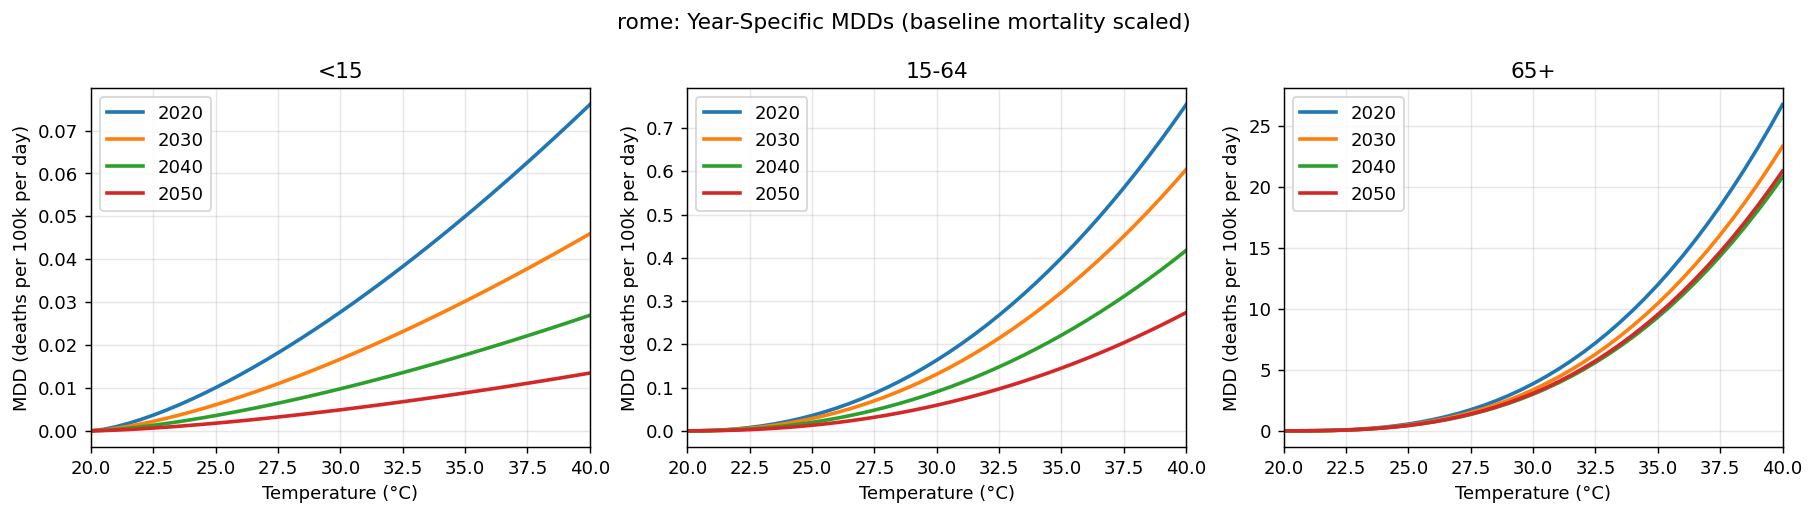

In [80]:
# Visualize the year-specific MDDs
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, age_lbl in enumerate(["<15", "15-64", "65+"]):
    ax = axes[i]
    
    for year in IF_YEARS:
        mdd = age_ifs_by_year[year][age_lbl].mdd
        ax.plot(T_arr, mdd * 1e5, label=f"{year}", linewidth=2)
    
    ax.set_xlabel("Temperature (°C)")
    ax.set_ylabel("MDD (deaths per 100k per day)")
    ax.set_title(f"{age_lbl}")
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_xlim(20, 40)

plt.suptitle(f"{CITY}: Year-Specific MDDs (baseline mortality scaled)", fontsize=12)
plt.tight_layout()
plt.savefig(OUT / f"{SLUG}_mdd_by_year.png", dpi=150)
plt.show()

**saving**

In [81]:
from pathlib import Path
import json

# Year-specific IFs with scaled MDD
freeze_dict_by_year = {}

for year in IF_YEARS:
    freeze_dict_by_year[year] = {}
    for age_lbl, f in age_ifs_by_year[year].items():
        freeze_dict_by_year[year][age_lbl] = {
            "id": int(f.id),
            "name": f.name,
            "intensity": np.asarray(f.intensity, float).tolist(),
            "mdd": np.asarray(f.mdd, float).tolist(),
        }

output = {
    "reference_year": MDD_REF_YEAR,
    "years": IF_YEARS,
    "scaling_source": "Wittgenstein ASSR baseline mortality",
    "ifs_by_year": freeze_dict_by_year,
}

freeze_path = Path(INT) / f"if_curves_by_year_{SLUG}.json"
with open(freeze_path, "w") as fh:
    json.dump(output, fh, indent=2)
print(f"✓ Saved year-specific IFs to: {freeze_path}")

# Legacy format (reference year only, for backward compatibility)
legacy_path = Path(INT) / f"if_curves_frozen_{SLUG}.json"
with open(legacy_path, "w") as fh:
    json.dump(freeze_dict_by_year[MDD_REF_YEAR], fh, indent=2)
print(f"✓ Saved legacy IFs (year {MDD_REF_YEAR}) to: {legacy_path}")

# DOCUMENTATION: Scaling factors
sf_path = Path(INT) / f"baseline_heat_scaling_{SLUG}.csv"
scale_factors.to_csv(sf_path)
print(f"✓ Saved scaling factors (documentation) → {sf_path}")

# DIAGNOSTICS: Raw heat deaths (for QA only)
# Manual (city-mean T) — no scaling, just for comparison
manual_raw_path = Path(INT) / f"annual_heat_deaths_manual_{SLUG}.csv"
annual_by_age.to_csv(manual_raw_path)
print(f"✓ Saved manual heat deaths (diagnostic) → {manual_raw_path}")

# Generic CLIMADA (2030 exposure, unscaled IF) — no scaling
generic_raw_path = Path(INT) / f"annual_heat_deaths_generic_{SLUG}.csv"
heat_deaths_generic.index = heat_deaths_generic.index.astype(int)
heat_deaths_generic.index.name = "year"
heat_deaths_generic.to_csv(generic_raw_path)
print(f"✓ Saved generic CLIMADA deaths (diagnostic) → {generic_raw_path}")

✓ Saved year-specific IFs to: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/if_curves_by_year_rome.json
✓ Saved legacy IFs (year 2020) to: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/if_curves_frozen_rome.json
✓ Saved scaling factors (documentation) → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/baseline_heat_scaling_rome.csv
✓ Saved manual heat deaths (diagnostic) → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/annual_heat_deaths_manual_rome.csv
✓ Saved generic CLIMADA deaths (diagnostic) → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/annual_heat_deaths_generic_rome.csv


# For the Early-Warning System

NOT NECESSARILY THE RIGHT PLACE (was just the easiest right now)

In [82]:
daily_df = pd.DataFrame({
    "date": dates,
    "citymean_degC": citymean_daily
})
daily_df["year"] = daily_df["date"].dt.year
daily_df["month"] = daily_df["date"].dt.month
daily_df["doy"] = daily_df["date"].dt.dayofyear

print("=" * 70)
print("EWS THRESHOLD ANALYSIS: Rome Daily T2M Statistics")
print("=" * 70)

EWS THRESHOLD ANALYSIS: Rome Daily T2M Statistics


In [84]:
WARM_MONTHS = [5, 6, 7, 8, 9]  # May through September

# filtering to warm season
warm_df = daily_df[daily_df["month"].isin(WARM_MONTHS)].copy()

print(f"\n1. WARM SEASON (May-Sep) STATISTICS BY YEAR:")
print("-" * 50)

for year in sorted(daily_df["year"].unique()):
    year_warm = warm_df[warm_df["year"] == year]["citymean_degC"]
    print(f"\n  {year}:")
    print(f"    N days: {len(year_warm)}")
    print(f"    Mean: {year_warm.mean():.2f}°C")
    print(f"    Max:  {year_warm.max():.2f}°C")
    print(f"    Min:  {year_warm.min():.2f}°C")
    print(f"    Std:  {year_warm.std():.2f}°C")


1. WARM SEASON (May-Sep) STATISTICS BY YEAR:
--------------------------------------------------

  2020:
    N days: 153
    Mean: 23.28°C
    Max:  28.20°C
    Min:  16.42°C
    Std:  3.27°C

  2030:
    N days: 153
    Mean: 23.77°C
    Max:  28.71°C
    Min:  16.90°C
    Std:  3.27°C

  2040:
    N days: 153
    Mean: 23.96°C
    Max:  28.94°C
    Min:  17.04°C
    Std:  3.30°C

  2050:
    N days: 153
    Mean: 23.83°C
    Max:  28.73°C
    Min:  16.92°C
    Std:  3.28°C


In [85]:
print(f"\n\n2. PERCENTILE THRESHOLDS (Warm Season, May-Sep):")
print("-" * 50)

percentiles = [99, 95, 90, 85, 80, 75]

# computing percentiles by year
pctl_by_year = {}
for year in sorted(daily_df["year"].unique()):
    year_warm = warm_df[warm_df["year"] == year]["citymean_degC"]
    pctl_by_year[year] = {p: np.percentile(year_warm, p) for p in percentiles}

# printing table
print(f"\n{'Year':<6}", end="")
for p in percentiles:
    print(f"{p}th%".rjust(8), end="")
print()
print("-" * (6 + 8*len(percentiles)))

for year, pctls in pctl_by_year.items():
    print(f"{year:<6}", end="")
    for p in percentiles:
        print(f"{pctls[p]:>7.1f}°", end="")
    print()

# average across years
print("-" * (6 + 8*len(percentiles)))
print(f"{'Mean':<6}", end="")
for p in percentiles:
    mean_pctl = np.mean([pctl_by_year[y][p] for y in pctl_by_year])
    print(f"{mean_pctl:>7.1f}°", end="")
print()



2. PERCENTILE THRESHOLDS (Warm Season, May-Sep):
--------------------------------------------------

Year     99th%   95th%   90th%   85th%   80th%   75th%
------------------------------------------------------
2020     27.9°   27.4°   26.7°   26.5°   26.3°   26.2°
2030     28.4°   27.9°   27.2°   27.0°   26.8°   26.7°
2040     28.7°   28.2°   27.4°   27.2°   27.0°   26.9°
2050     28.5°   28.0°   27.2°   27.0°   26.9°   26.7°
------------------------------------------------------
Mean     28.4°   27.9°   27.1°   26.9°   26.7°   26.6°


In [86]:
print(f"\n\n3. WARNING DAYS COUNT (days with T ≥ threshold):")
print("-" * 50)

# testing thresholds
thresholds = [30, 29, 28, 27, 26, 25, 24, 23]

# count by year
counts_by_year = {}
for year in sorted(daily_df["year"].unique()):
    year_warm = warm_df[warm_df["year"] == year]["citymean_degC"]
    counts_by_year[year] = {t: (year_warm >= t).sum() for t in thresholds}

# print table
print(f"\n{'Year':<6}", end="")
for t in thresholds:
    print(f"≥{t}°C".rjust(8), end="")
print()
print("-" * (6 + 8*len(thresholds)))

for year, counts in counts_by_year.items():
    print(f"{year:<6}", end="")
    for t in thresholds:
        print(f"{counts[t]:>7}d", end="")
    print()

# avg across years
print("-" * (6 + 8*len(thresholds)))
print(f"{'Mean':<6}", end="")
for t in thresholds:
    mean_count = np.mean([counts_by_year[y][t] for y in counts_by_year])
    print(f"{mean_count:>6.1f}d", end="")
print()



3. WARNING DAYS COUNT (days with T ≥ threshold):
--------------------------------------------------

Year     ≥30°C   ≥29°C   ≥28°C   ≥27°C   ≥26°C   ≥25°C   ≥24°C   ≥23°C
----------------------------------------------------------------------
2020        0d      0d      2d     11d     45d     65d     74d     87d
2030        0d      0d      8d     20d     59d     70d     83d     95d
2040        0d      0d      9d     35d     62d     70d     84d     95d
2050        0d      0d      8d     26d     60d     70d     84d     95d
----------------------------------------------------------------------
Mean     0.0d   0.0d   6.8d  23.0d  56.5d  68.8d  81.2d  93.0d


In [87]:
print(f"\n\n4. ANNUAL WARNING DAYS (Full Year, not just warm season):")
print("-" * 50)

# count by year (full year)
annual_counts = {}
for year in sorted(daily_df["year"].unique()):
    year_all = daily_df[daily_df["year"] == year]["citymean_degC"]
    annual_counts[year] = {t: (year_all >= t).sum() for t in thresholds}

# print table
print(f"\n{'Year':<6}", end="")
for t in thresholds:
    print(f"≥{t}°C".rjust(8), end="")
print()
print("-" * (6 + 8*len(thresholds)))

for year, counts in annual_counts.items():
    print(f"{year:<6}", end="")
    for t in thresholds:
        print(f"{counts[t]:>7}d", end="")
    print()



4. ANNUAL WARNING DAYS (Full Year, not just warm season):
--------------------------------------------------

Year     ≥30°C   ≥29°C   ≥28°C   ≥27°C   ≥26°C   ≥25°C   ≥24°C   ≥23°C
----------------------------------------------------------------------
2020        0d      0d      2d     11d     45d     65d     74d     87d
2030        0d      0d      8d     20d     59d     70d     83d     95d
2040        0d      0d      9d     35d     62d     70d     84d     95d
2050        0d      0d      8d     26d     60d     70d     84d     95d


In [88]:
print(f"\n\n5. RECOMMENDED THRESHOLD FOR EWS:")
print("-" * 50)

# 2020 as baseline reference
ref_year = 2020
if ref_year in pctl_by_year:
    p90 = pctl_by_year[ref_year][90]
    p95 = pctl_by_year[ref_year][95]
    
    print(f"\n  Based on {ref_year} warm season:")
    print(f"    90th percentile: {p90:.1f}°C")
    print(f"    95th percentile: {p95:.1f}°C")
    
    # Days at these thresholds
    n_p90 = counts_by_year[ref_year].get(round(p90), "N/A")
    n_p95 = counts_by_year[ref_year].get(round(p95), "N/A")
    
    print(f"\n  Recommendation:")
    print(f"    Use {round(p90)}°C as threshold (≈90th percentile)")
    print(f"    This gives ~{counts_by_year[ref_year][round(p90)]} warning days/year in warm season")



5. RECOMMENDED THRESHOLD FOR EWS:
--------------------------------------------------

  Based on 2020 warm season:
    90th percentile: 26.7°C
    95th percentile: 27.4°C

  Recommendation:
    Use 27°C as threshold (≈90th percentile)
    This gives ~11 warning days/year in warm season


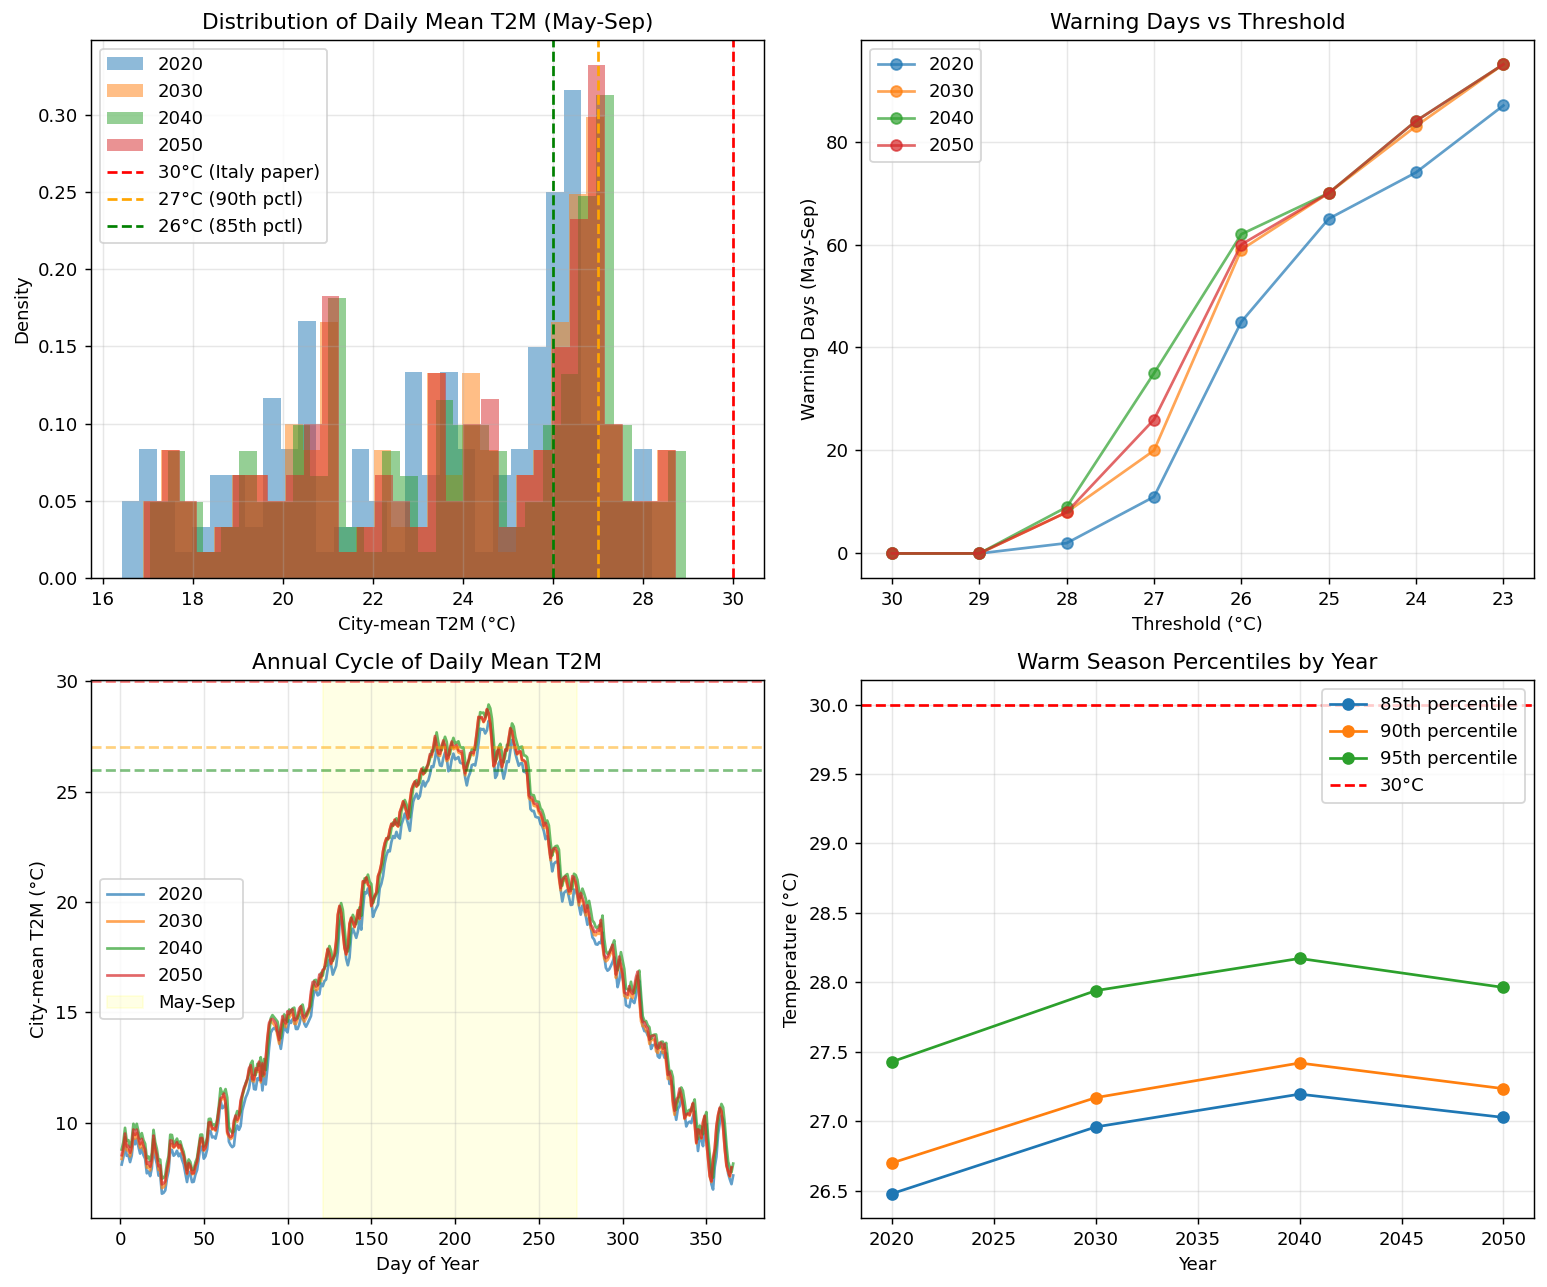


Figure saved to: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/figures/rome_ews_threshold_analysis.png


In [89]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Daily T2M distribution by year (warm season)
ax1 = axes[0, 0]
for year in sorted(daily_df["year"].unique()):
    year_warm = warm_df[warm_df["year"] == year]["citymean_degC"]
    ax1.hist(year_warm, bins=30, alpha=0.5, label=str(year), density=True)
ax1.axvline(x=30, color='red', linestyle='--', label='30°C (Italy paper)')
ax1.axvline(x=27, color='orange', linestyle='--', label='27°C (90th pctl)')
ax1.axvline(x=26, color='green', linestyle='--', label='26°C (85th pctl)')  # Updated
ax1.set_xlabel('City-mean T2M (°C)')
ax1.set_ylabel('Density')
ax1.set_title('Distribution of Daily Mean T2M (May-Sep)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Warning days vs threshold
ax2 = axes[0, 1]
for year in sorted(daily_df["year"].unique()):
    days = [counts_by_year[year][t] for t in thresholds]
    ax2.plot(thresholds, days, 'o-', label=str(year), alpha=0.7)
ax2.set_xlabel('Threshold (°C)')
ax2.set_ylabel('Warning Days (May-Sep)')
ax2.set_title('Warning Days vs Threshold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.invert_xaxis()

# Time series of daily T2M
ax3 = axes[1, 0]
for year in sorted(daily_df["year"].unique()):
    year_df = daily_df[daily_df["year"] == year]
    ax3.plot(year_df["doy"], year_df["citymean_degC"], label=str(year), alpha=0.7)
ax3.axhline(y=30, color='red', linestyle='--', alpha=0.5)
ax3.axhline(y=27, color='orange', linestyle='--', alpha=0.5)
ax3.axhline(y=26, color='green', linestyle='--', alpha=0.5)  # Updated
ax3.axvspan(121, 273, alpha=0.1, color='yellow', label='May-Sep')
ax3.set_xlabel('Day of Year')
ax3.set_ylabel('City-mean T2M (°C)')
ax3.set_title('Annual Cycle of Daily Mean T2M')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Percentile trend
ax4 = axes[1, 1]
years = sorted(pctl_by_year.keys())
for p in [85, 90, 95]: 
    vals = [pctl_by_year[y][p] for y in years]
    ax4.plot(years, vals, 'o-', label=f'{p}th percentile')
ax4.axhline(y=30, color='red', linestyle='--', label='30°C')
ax4.set_xlabel('Year')
ax4.set_ylabel('Temperature (°C)')
ax4.set_title('Warm Season Percentiles by Year')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()

# figures directory if needed
fig_dir = OUT / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(fig_dir / "rome_ews_threshold_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFigure saved to: {fig_dir / 'rome_ews_threshold_analysis.png'}")

In [91]:
# summary DataFrame for NB6
ews_threshold_data = []
for year in sorted(daily_df["year"].unique()):
    row = {
        'year': year,
        'n_warm_days': len(warm_df[warm_df["year"] == year]),
        'mean_warm_T': warm_df[warm_df["year"] == year]["citymean_degC"].mean(),
        'max_warm_T': warm_df[warm_df["year"] == year]["citymean_degC"].max(),
        'pctl_90': pctl_by_year[year][90],
        'pctl_95': pctl_by_year[year][95],
    }
    # counts for key thresholds
    for t in [30, 28, 27, 26, 25]:
        row[f'days_ge_{t}'] = counts_by_year[year][t]
    ews_threshold_data.append(row)

ews_threshold_df = pd.DataFrame(ews_threshold_data)
ews_threshold_df.to_csv(OUT / "tables/rome_ews_threshold_analysis.csv", index=False)
print(f"\nThreshold analysis saved to: {OUT / 'tables/rome_ews_threshold_analysis.csv'}")

print("\n" + "=" * 70)
print("SUMMARY FOR NB5b:")
print("=" * 70)
print(ews_threshold_df.to_string(index=False))


Threshold analysis saved to: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/tables/rome_ews_threshold_analysis.csv

SUMMARY FOR NB5b:
 year  n_warm_days  mean_warm_T  max_warm_T   pctl_90   pctl_95  days_ge_30  days_ge_28  days_ge_27  days_ge_26  days_ge_25
 2020          153    23.275384   28.198851 26.700296 27.428740           0           2          11          45          65
 2030          153    23.773727   28.710996 27.170641 27.940885           0           8          20          59          70
 2040          153    23.957669   28.942621 27.419952 28.172510           0           9          35          62          70
 2050          153    23.826154   28.733915 27.235360 27.963804           0           8          26          60          70
